# Smart Tile Scheduling for a 32x32 Weight-Stationary Systolic Array

The goal is to reason about when a tiled schedule is memory-bound or compute-bound when a single DRAM channel feeds a 32x32 systolic array.

Notebook summary:

1. Define the hardware and modeling assumptions.
2. Build an event-driven simulator for tiled loads and tile-GEMM dispatch.
3. Plot DRAM-load and array-compute timelines.
4. Sweep reuse-block sizes `M` and `N` to study utilization trends.

## Model Assumptions

We model a tiled matrix multiply at the tile level.

- Weight matrix tiles are indexed as `W_m_k`.
- Input matrix tiles are indexed as `I_k_n`.
- Output tiles are `O_m_n = sum_k W_m_k @ I_k_n`.
- One tile-GEMM takes a fixed `32` compute cycles.
- One tile load uses a single DRAM channel with `8` bytes/cycle bandwidth.
- A `32 x 32` FP16 tile is `32 * 32 * 2 = 2048` bytes, so the ideal load cost is `256` cycles.
- Scratchpad is modeled as effectively infinite, so the notebook focuses on scheduling rather than eviction.

The reusable scheduling knob is a block size `(M, N)`:

- `M`: how many weight-row tiles are reused together.
- `N`: how many input-column tiles are reused together.

Per `(k, m_block, n_block)`, the simulator loads `M` weight tiles and up to `N` input tiles, then dispatches any GEMMs whose operands are already resident.

In [1]:
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt


COMPUTE_CYCLES = 32
TILE_BYTES = 32 * 32 * 2
DRAM_BW = 8
LOAD_CYCLES = TILE_BYTES // DRAM_BW  # 256 cycles
WEIGHT_SWITCH_DRAIN = COMPUTE_CYCLES
OUTPUT_DIR = Path.cwd() / "smart_tile_scheduling_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tile bytes: {TILE_BYTES}")
print(f"Load cycles per tile: {LOAD_CYCLES}")
print(f"Plots will be written under: {OUTPUT_DIR}")

Tile bytes: 2048
Load cycles per tile: 256
Plots will be written under: /home/asicfab/a/socet149/atalla-sim/docs/smart_tile_scheduling_outputs


## Lightweight Event Records

The simulator tracks two kinds of events:

- `TileLoad`: one DRAM-to-scratchpad tile transfer.
- `GemmOp`: one tile-GEMM scheduled on the array.

These classes keep the logs compact and make plotting easier later.

In [2]:
class TileLoad:
    __slots__ = ("tile_id", "kind", "start", "end")

    def __init__(self, tile_id, kind, start):
        self.tile_id = tile_id
        self.kind = kind
        self.start = start
        self.end = start + LOAD_CYCLES


class GemmOp:
    __slots__ = ("weight_id", "input_id", "key", "start", "end")

    def __init__(self, w_id, i_id, key):
        self.weight_id = w_id
        self.input_id = i_id
        self.key = key
        self.start = None
        self.end = None

## Simulator Core

The simulator maintains three main pieces of state:

- `w_resident[m][k]`: whether weight tile `W_m_k` is loaded.
- `i_resident[k][n]`: whether input tile `I_k_n` is loaded.
- `ready_queue`: tile-GEMMs whose operands are both resident and can be dispatched.

As soon as a tile arrives, the simulator checks which GEMMs become ready and appends them to the queue. That keeps dispatch logic simple and makes the event loop `O(1)` per ready operation.

In [3]:
class SystolicArraySim:
    """
    Event-driven simulator with O(1) GEMM dispatch.

    Tiling parameters M, N:
      M = number of weight-row tiles per block
      N = number of input-column tiles per block
    """

    def __init__(self, Mw=32, K=32, Ni=32, M=32, N=32):
        assert Mw % M == 0, f"Mw={Mw} must be divisible by M={M}"
        assert Ni % N == 0, f"Ni={Ni} must be divisible by N={N}"
        self.Mw = Mw
        self.K = K
        self.Ni = Ni
        self.M = M
        self.N = N

        self.gemm_ops = {}
        self.pending = set()
        for m in range(Mw):
            for k in range(K):
                for n in range(Ni):
                    key = (m, k, n)
                    self.gemm_ops[key] = GemmOp(f"W_{m}_{k}", f"I_{k}_{n}", key)
                    self.pending.add(key)

        self.w_resident = [[False] * K for _ in range(Mw)]
        self.i_resident = [[False] * Ni for _ in range(K)]
        self.ready_queue = deque()

        self.load_log = []
        self.gemm_log = []
        self.idle_cycles = 0
        self.drain_cycles = 0
        self.total_cycles = 0

    def _arrive_weight(self, m, k):
        self.w_resident[m][k] = True
        for n in range(self.Ni):
            if self.i_resident[k][n]:
                key = (m, k, n)
                if key in self.pending:
                    self.ready_queue.append(key)

    def _arrive_input(self, k, n):
        self.i_resident[k][n] = True
        for m in range(self.Mw):
            if self.w_resident[m][k]:
                key = (m, k, n)
                if key in self.pending:
                    self.ready_queue.append(key)

    def _build_load_sequence(self):
        seq = []
        loaded_inputs = set()
        for k in range(self.K):
            for m0 in range(0, self.Mw, self.M):
                for n0 in range(0, self.Ni, self.N):
                    for m in range(m0, m0 + self.M):
                        seq.append(("W", m, k))
                    for n in range(n0, n0 + self.N):
                        if (k, n) not in loaded_inputs:
                            seq.append(("I", k, n))
                            loaded_inputs.add((k, n))
        return seq

In [4]:
def _sim_run(self):
    load_seq = self._build_load_sequence()
    load_idx = 0
    load_end = 0
    compute_end = 0
    inflight = []

    total_ops = len(self.pending)
    done_ops = 0
    n_loads = len(load_seq)
    max_cycles = n_loads * LOAD_CYCLES + total_ops * COMPUTE_CYCLES + 100_000

    cycle = 0
    while done_ops < total_ops and cycle < max_cycles:
        remaining = []
        for item in inflight:
            kind, r, c, end = item
            if end <= cycle:
                if kind == "W":
                    self._arrive_weight(r, c)
                else:
                    self._arrive_input(r, c)
            else:
                remaining.append(item)
        inflight = remaining

        if cycle >= load_end and load_idx < n_loads:
            kind, r, c = load_seq[load_idx]
            load_idx += 1
            tile_id = f"W_{r}_{c}" if kind == "W" else f"I_{r}_{c}"
            tl = TileLoad(tile_id, "weight" if kind == "W" else "input", cycle)
            self.load_log.append(tl)
            inflight.append((kind, r, c, tl.end))
            load_end = tl.end

        if cycle >= compute_end:
            while self.ready_queue and self.ready_queue[0] not in self.pending:
                self.ready_queue.popleft()

            if self.ready_queue:
                key = self.ready_queue.popleft()
                self.pending.discard(key)
                op = self.gemm_ops[key]
                op.start = cycle
                op.end = cycle + COMPUTE_CYCLES
                compute_end = op.end
                self.gemm_log.append(op)
                done_ops += 1
            else:
                self.idle_cycles += 1

        cycle += 1

    self.total_cycles = cycle
    return self


def _sim_metrics(self):
    total = self.total_cycles
    compute_cyc = sum(op.end - op.start for op in self.gemm_log)
    bw_active = len(self.load_log) * LOAD_CYCLES

    switches = 0
    switch_drain_total = 0
    for i in range(1, len(self.gemm_log)):
        prev, cur = self.gemm_log[i - 1], self.gemm_log[i]
        if cur.weight_id != prev.weight_id:
            switches += 1
            gap = cur.start - prev.end
            if gap > 0:
                switch_drain_total += gap

    return {
        "total_cycles": total,
        "compute_cycles": compute_cyc,
        "array_util_pct": compute_cyc / total * 100,
        "bw_active_cycles": bw_active,
        "bw_util_pct": bw_active / total * 100,
        "idle_cycles": self.idle_cycles,
        "weight_switches": switches,
        "switch_drain_cyc": switch_drain_total,
        "tiles_loaded": len(self.load_log),
        "gemms_completed": len(self.gemm_log),
        "total_gemms": self.Mw * self.K * self.Ni,
    }


SystolicArraySim.run = _sim_run
SystolicArraySim.metrics = _sim_metrics

## Timeline Plotting

The plotting cell recreates the script's three-panel view:

- DRAM load timeline
- array compute Gantt
- utilization summary

Red shading in the DRAM panel marks channel idle time. Gray shading in the compute panel marks array idle time.

In [5]:
def plot_timeline(sim, label="", max_display_cycles=40_000):
    metrics = sim.metrics()
    limit = min(max_display_cycles, sim.total_cycles)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(20, 10),
        gridspec_kw={"height_ratios": [1.4, 1.4, 1]},
    )
    fig.suptitle(
        (
            f"32x32 Systolic Array | W:{sim.Mw}x{sim.K} I:{sim.K}x{sim.Ni} "
            f"Block M={sim.M} N={sim.N} {label}\n"
            f"Array util: {metrics['array_util_pct']:.1f}%   "
            f"BW util: {metrics['bw_util_pct']:.1f}%   "
            f"Weight switches: {metrics['weight_switches']:,}   "
            f"Switch drain: {metrics['switch_drain_cyc']:,} cyc   "
            f"Total: {metrics['total_cycles']:,} cyc"
        ),
        fontsize=11,
        fontweight="bold",
    )
    palette = plt.cm.tab20.colors

    ax0 = axes[0]
    prev_end = 0
    for tile_load in sim.load_log:
        if tile_load.start >= limit:
            break
        end = min(tile_load.end, limit)
        y = 0 if tile_load.kind == "weight" else 1
        idx = int(tile_load.tile_id.split("_")[2])
        ax0.barh(
            y,
            end - tile_load.start,
            left=tile_load.start,
            height=0.6,
            color=palette[idx % len(palette)],
            edgecolor="white",
            linewidth=0.2,
        )
        if tile_load.start > prev_end:
            ax0.axvspan(prev_end, min(tile_load.start, limit), color="red", alpha=0.2, zorder=0)
        prev_end = max(prev_end, tile_load.end)
    if prev_end < limit:
        ax0.axvspan(prev_end, limit, color="red", alpha=0.2, zorder=0)
    ax0.set_yticks([0, 1])
    ax0.set_yticklabels(["Weights", "Inputs"], fontsize=10)
    ax0.set_xlim(0, limit)
    ax0.set_title("DRAM -> Scratchpad (colour = k, red = BW idle)", fontsize=10)

    ax1 = axes[1]
    prev_end = 0
    for op in sim.gemm_log:
        if op.start >= limit:
            break
        end = min(op.end, limit)
        k_idx = int(op.weight_id.split("_")[2])
        if op.start > prev_end:
            ax1.axvspan(prev_end, min(op.start, limit), color="lightgray", alpha=0.6, zorder=0)
        ax1.barh(
            0,
            end - op.start,
            left=op.start,
            height=0.6,
            color=palette[k_idx % len(palette)],
            edgecolor="white",
            linewidth=0.2,
        )
        prev_end = max(prev_end, end)
    if prev_end < limit:
        ax1.axvspan(prev_end, limit, color="lightgray", alpha=0.6, zorder=0)
    ax1.set_yticks([0])
    ax1.set_yticklabels(["Array"], fontsize=10)
    ax1.set_xlim(0, limit)
    ax1.set_title("Compute Gantt (colour = k, gray = idle)", fontsize=10)
    ax1.set_xlabel(f"Cycle (first {limit:,} of {metrics['total_cycles']:,} shown)")

    ax2 = axes[2]
    categories = ["Array util", "BW util"]
    values = [metrics["array_util_pct"], metrics["bw_util_pct"]]
    colors = ["#4C72B0", "#DD8452"]
    bars = ax2.barh(categories, values, color=colors, height=0.4)
    ax2.set_xlim(0, 115)
    ax2.axvline(100, color="black", lw=1, linestyle="--")
    for bar, value in zip(bars, values):
        ax2.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=11)
    ax2.set_title("Utilization summary", fontsize=10)
    ax2.set_xlabel("Utilization (%)")

    plt.tight_layout()
    output_path = OUTPUT_DIR / f"systolic_timeline_M{sim.M}_N{sim.N}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot -> {output_path}")
    return output_path

## Analysis Helpers

These helpers wrap the simulator in the same style as the original script:

- `run_simulation(...)` prints a block-level bound estimate, runs the simulator, and optionally plots a timeline.
- `sweep_MN(...)` sweeps reuse block sizes to see when the schedule becomes compute-dominated.

In [6]:
def run_simulation(Mw=32, K=32, Ni=32, M=32, N=32, verbose=True, plot=True):
    n_blocks = (Mw // M) * (Ni // N) * K
    load_per_block = (M + N) * LOAD_CYCLES
    compute_per_block = M * N * COMPUTE_CYCLES
    bound = "COMPUTE" if compute_per_block > load_per_block else "MEMORY"

    print(f"\n{'=' * 70}")
    print(f"  W:{Mw}x{K} tiles   I:{K}x{Ni} tiles   Block M={M} N={N}")
    print(f"  Total GEMMs : {Mw * K * Ni:,}   Blocks: {n_blocks:,}")
    print(
        f"  Per block: load {M + N} tiles ({load_per_block:,} cyc)  "
        f"compute {M * N} GEMMs ({compute_per_block:,} cyc)  -> {bound}"
    )
    print(
        "  Theoretical max array util (if no overhead): "
        f"{min(100, compute_per_block / load_per_block * 100):.1f}%"
    )
    print(f"{'=' * 70}")

    sim = SystolicArraySim(Mw, K, Ni, M, N).run()
    metrics = sim.metrics()

    print(f"  Total cycles      : {metrics['total_cycles']:,}")
    print(f"  Array util        : {metrics['array_util_pct']:.2f}%")
    print(f"  BW util           : {metrics['bw_util_pct']:.2f}%")
    print(f"  Weight switches   : {metrics['weight_switches']:,}")
    print(
        f"  Switch drain cyc  : {metrics['switch_drain_cyc']:,}  "
        f"({metrics['switch_drain_cyc'] / metrics['total_cycles'] * 100:.2f}% of total)"
    )
    print(
        f"  Array idle cyc    : {metrics['idle_cycles']:,}  "
        f"({metrics['idle_cycles'] / metrics['total_cycles'] * 100:.2f}% of total)"
    )

    if verbose:
        print("\n  First 8 GEMMs:")
        for op in sim.gemm_log[:8]:
            print(f"    {op.start:>8,}-{op.end:<8,}  {op.weight_id} x {op.input_id}")

    if plot:
        plot_timeline(sim)
    return sim, metrics


def sweep_MN(Mw=32, K=32, Ni=32):
    print(f"\n{'=' * 70}")
    print(f"  M x N Reuse Sweep   (Mw={Mw}, K={K}, Ni={Ni})")
    print(f"  Load/tile={LOAD_CYCLES} cyc   Compute/tile={COMPUTE_CYCLES} cyc")
    print(f"  Compute-bound when M*N*{COMPUTE_CYCLES} > (M+N)*{LOAD_CYCLES}")
    print(f"{'=' * 70}")
    print(
        f"  {'M':>4} {'N':>4} {'Blk GEMMs':>10} {'Blk Load cyc':>13} "
        f"{'Blk Cmp cyc':>12} {'Bound':>8} {'Array%':>8} {'BW%':>7} {'SwitchDrain%':>13}"
    )
    print(f"  {'-' * 4} {'-' * 4} {'-' * 10} {'-' * 13} {'-' * 12} {'-' * 8} {'-' * 8} {'-' * 7} {'-' * 13}")

    results = []
    for M in [1, 2, 4, 8, 16, 32]:
        for N in [1, 2, 4, 8, 16, 32]:
            if Mw % M != 0 or Ni % N != 0:
                continue
            load_cycles = (M + N) * LOAD_CYCLES
            compute_cycles = M * N * COMPUTE_CYCLES
            bound = "COMPUTE" if compute_cycles > load_cycles else "MEMORY"
            sim, metrics = run_simulation(Mw, K, Ni, M, N, verbose=False, plot=False)
            drain_pct = metrics['switch_drain_cyc'] / metrics['total_cycles'] * 100
            print(
                f"  {M:>4} {N:>4} {M * N:>10,} {load_cycles:>13,} {compute_cycles:>12,} {bound:>8} "
                f"{metrics['array_util_pct']:>7.1f}% {metrics['bw_util_pct']:>6.1f}% {drain_pct:>12.2f}%"
            )
            results.append((M, N, metrics['array_util_pct'], metrics['bw_util_pct'], drain_pct))
    return results

## Recommended Execution Order

Start with one baseline run, then sweep `M` and `N`, then inspect a couple of intermediate reuse points.

Suggested order:

1. Run the baseline `M=32, N=32` case.
2. Run the reuse sweep.
3. Compare medium-reuse cases such as `(16, 16)` and `(8, 8)`.

Because the sweep executes many full simulations, it is left in its own cell so you can run it only when needed.


  W:32x32 tiles   I:32x32 tiles   Block M=32 N=32
  Total GEMMs : 32,768   Blocks: 32
  Per block: load 64 tiles (16,384 cyc)  compute 1024 GEMMs (32,768 cyc)  -> COMPUTE
  Theoretical max array util (if no overhead): 100.0%
  Total cycles      : 1,056,993
  Array util        : 99.20%
  BW util           : 49.60%
  Weight switches   : 32,767
  Switch drain cyc  : 0  (0.00% of total)
  Array idle cyc    : 8,448  (0.80% of total)

  First 8 GEMMs:
       8,448-8,480     W_0_0 x I_0_0
       8,480-8,512     W_1_0 x I_0_0
       8,512-8,544     W_2_0 x I_0_0
       8,544-8,576     W_3_0 x I_0_0
       8,576-8,608     W_4_0 x I_0_0
       8,608-8,640     W_5_0 x I_0_0
       8,640-8,672     W_6_0 x I_0_0
       8,672-8,704     W_7_0 x I_0_0


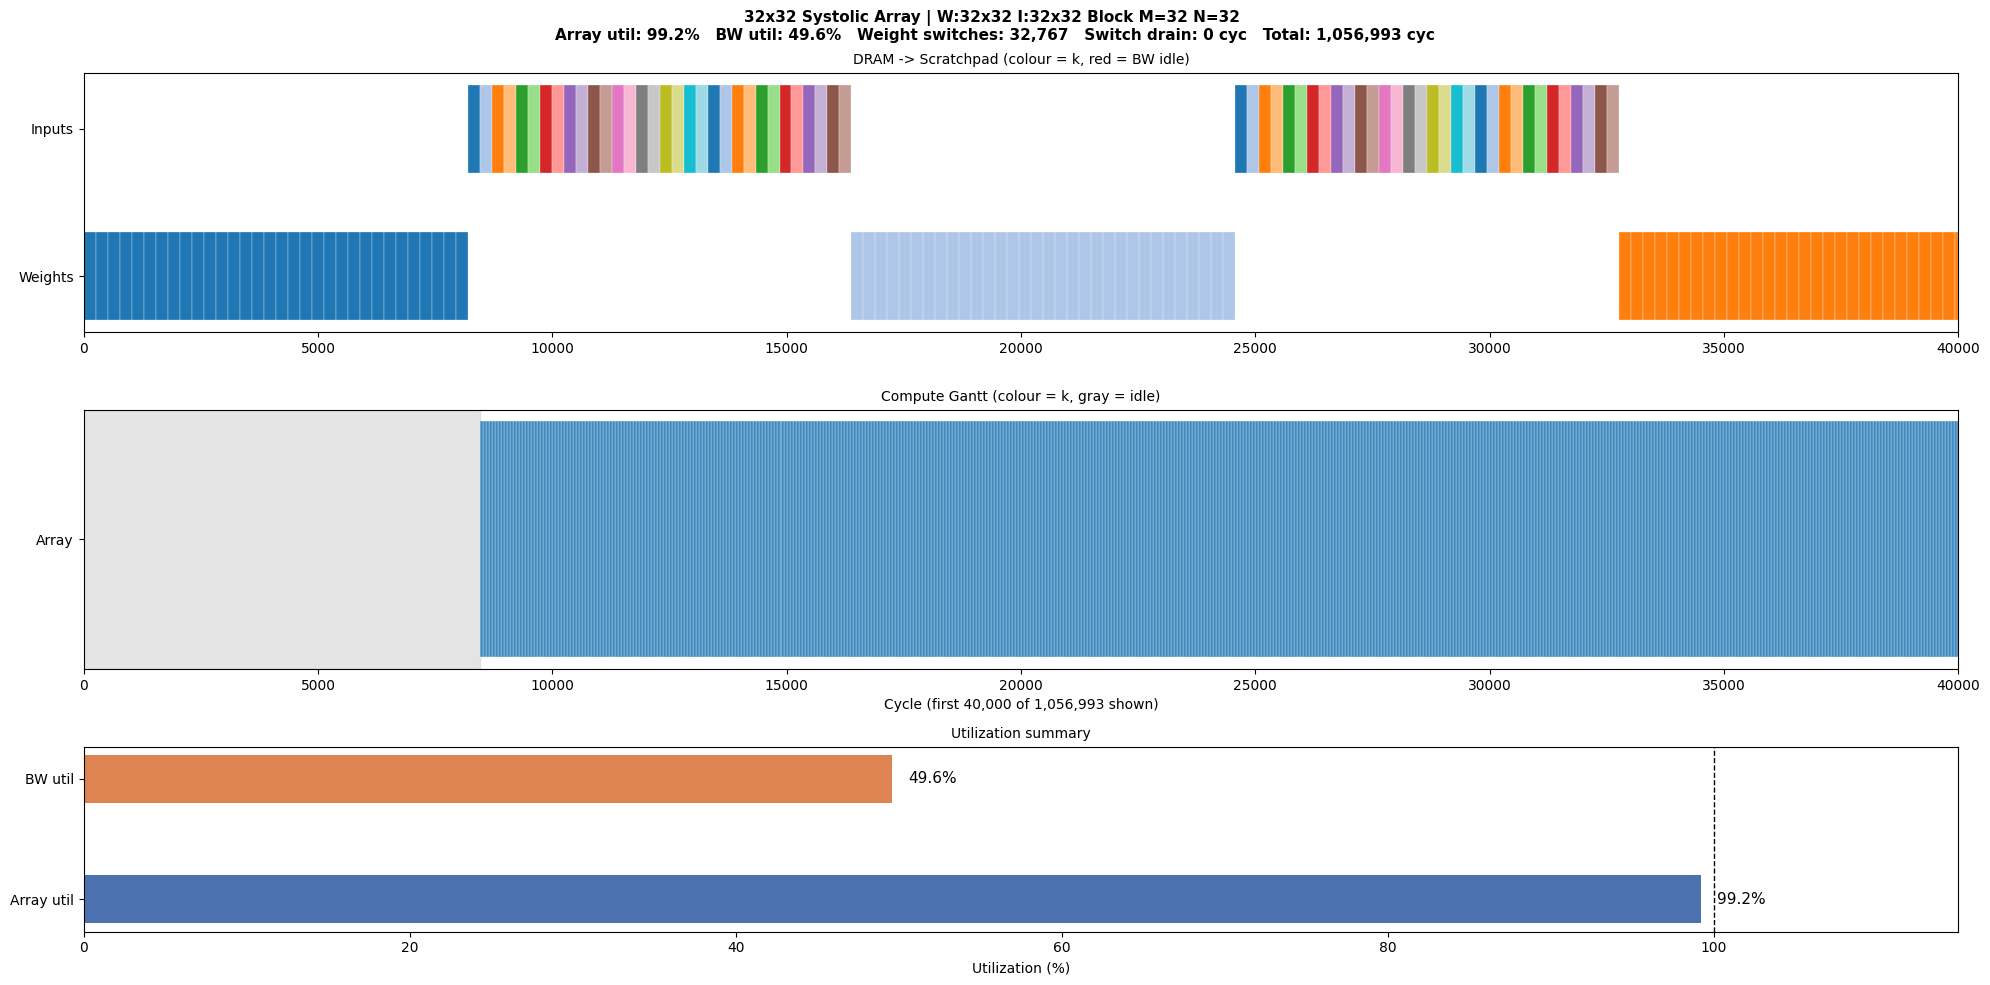

Plot -> /home/asicfab/a/socet149/atalla-sim/docs/smart_tile_scheduling_outputs/systolic_timeline_M32_N32.png


In [7]:
# Baseline run at full M=32, N=32 reuse.
# Uncomment and run this cell when you want the main timeline and summary.

sim_full, metrics_full = run_simulation(Mw=32, K=32, Ni=32, M=32, N=32, verbose=True, plot=True)
# metrics_full

In [8]:
# Sweep M and N reuse sizes.
# This is the main cell for finding the minimum reuse region where the schedule becomes compute-bound.

sweep_results = sweep_MN(32, 32, 32)
sweep_results[:5]


  M x N Reuse Sweep   (Mw=32, K=32, Ni=32)
  Load/tile=256 cyc   Compute/tile=32 cyc
  Compute-bound when M*N*32 > (M+N)*256
     M    N  Blk GEMMs  Blk Load cyc  Blk Cmp cyc    Bound   Array%     BW%  SwitchDrain%
  ---- ---- ---------- ------------- ------------ -------- -------- ------- -------------

  W:32x32 tiles   I:32x32 tiles   Block M=1 N=1
  Total GEMMs : 32,768   Blocks: 32,768
  Per block: load 2 tiles (512 cyc)  compute 1 GEMMs (32 cyc)  -> MEMORY
  Theoretical max array util (if no overhead): 6.2%
  Total cycles      : 8,643,809
  Array util        : 12.13%
  BW util           : 100.00%
  Weight switches   : 1,023
  Switch drain cyc  : 7,118,592  (82.35% of total)
  Array idle cyc    : 7,595,264  (87.87% of total)
     1    1          1           512           32   MEMORY    12.1%  100.0%        82.35%

  W:32x32 tiles   I:32x32 tiles   Block M=1 N=2
  Total GEMMs : 32,768   Blocks: 16,384
  Per block: load 3 tiles (768 cyc)  compute 2 GEMMs (64 cyc)  -> MEMORY
  Theor

[(1, 1, 12.130948289116523, 100.00035863818833, 82.35480446178299),
 (1, 2, 23.544453129052197, 100.00069606594752, 68.69623030891182),
 (1, 4, 44.45950111448096, 100.00131439641433, 43.667132076063695),
 (1, 8, 79.9862694468494, 99.98283680856176, 1.152145971036161),
 (1, 16, 99.25176127161775, 74.43882095371332, 0.02120246365055311)]


  W:32x32 tiles   I:32x32 tiles   Block M=16 N=16
  Total GEMMs : 32,768   Blocks: 128
  Per block: load 32 tiles (8,192 cyc)  compute 256 GEMMs (8,192 cyc)  -> MEMORY
  Theoretical max array util (if no overhead): 100.0%
  Total cycles      : 1,052,897
  Array util        : 99.59%
  BW util           : 74.69%
  Weight switches   : 16,895
  Switch drain cyc  : 0  (0.00% of total)
  Array idle cyc    : 4,352  (0.41% of total)

  First 8 GEMMs:
       4,352-4,384     W_0_0 x I_0_0
       4,384-4,416     W_1_0 x I_0_0
       4,416-4,448     W_2_0 x I_0_0
       4,448-4,480     W_3_0 x I_0_0
       4,480-4,512     W_4_0 x I_0_0
       4,512-4,544     W_5_0 x I_0_0
       4,544-4,576     W_6_0 x I_0_0
       4,576-4,608     W_7_0 x I_0_0


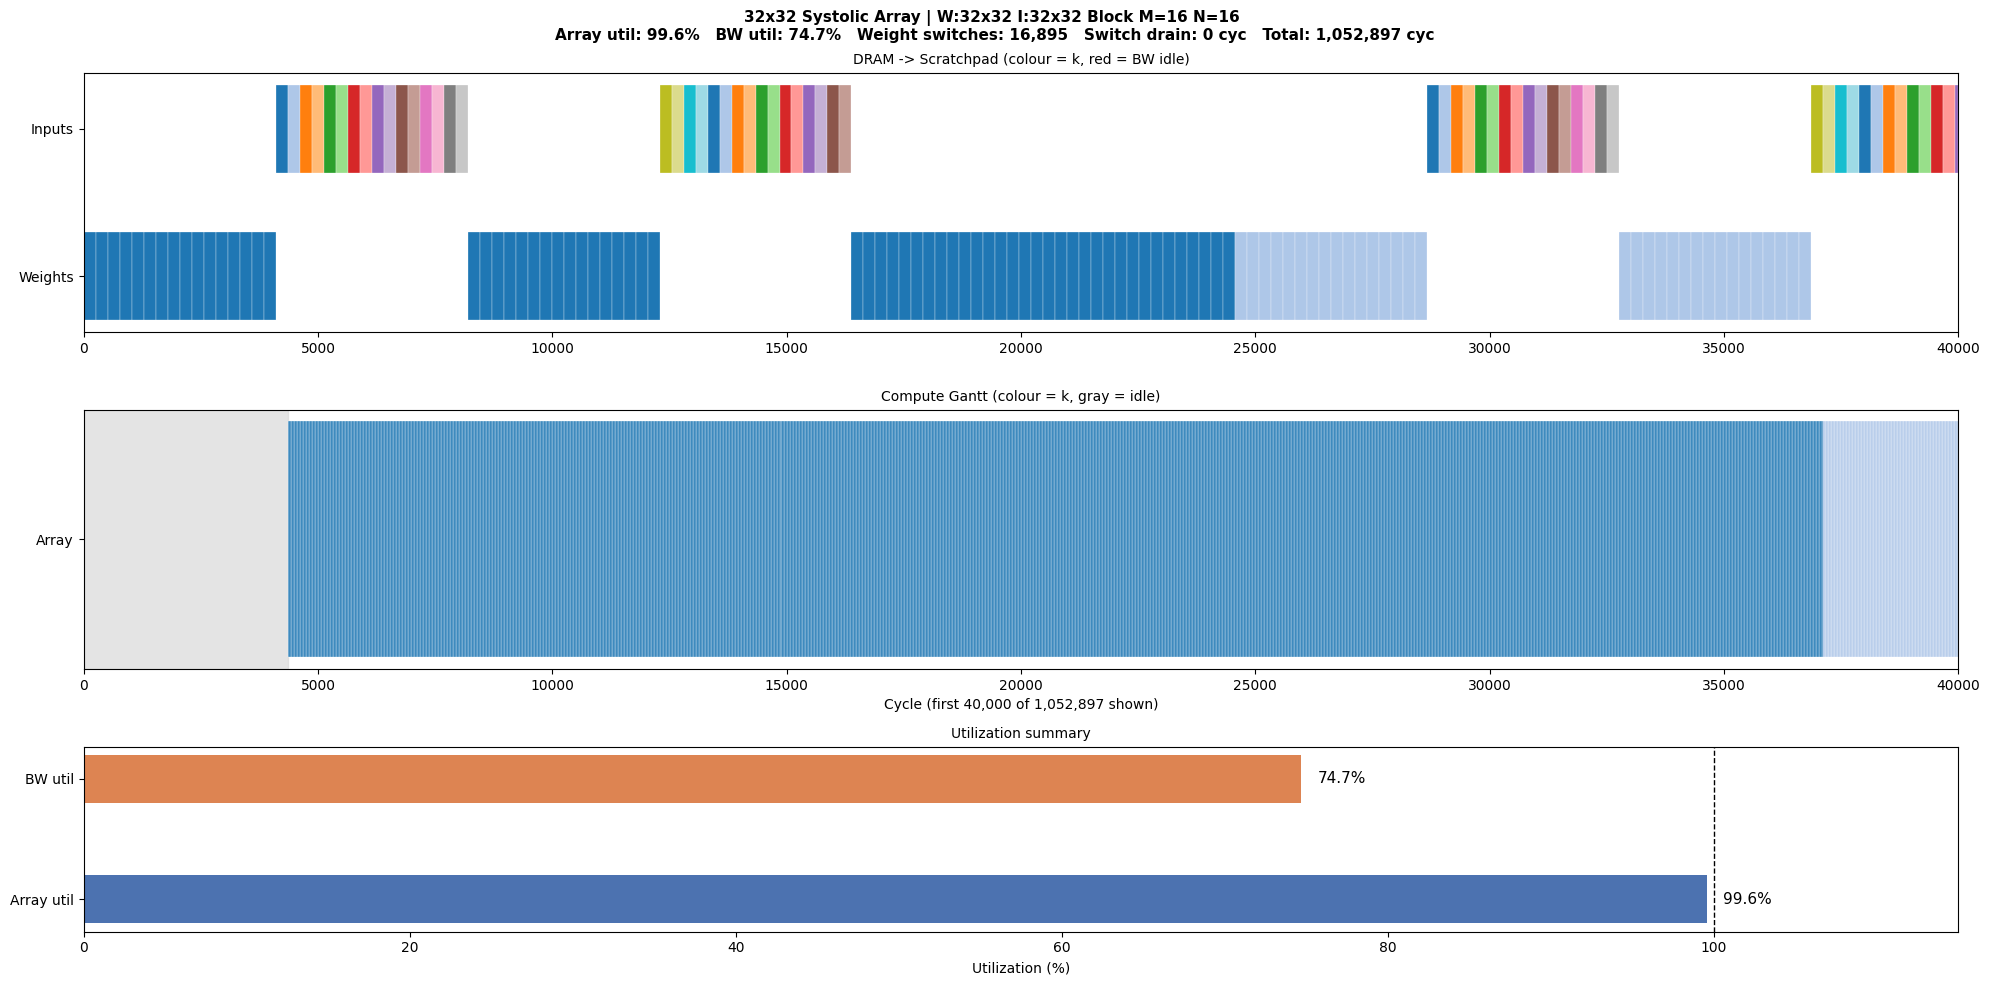

Plot -> /home/asicfab/a/socet149/atalla-sim/docs/smart_tile_scheduling_outputs/systolic_timeline_M16_N16.png

  W:32x32 tiles   I:32x32 tiles   Block M=8 N=8
  Total GEMMs : 32,768   Blocks: 512
  Per block: load 16 tiles (4,096 cyc)  compute 64 GEMMs (2,048 cyc)  -> MEMORY
  Theoretical max array util (if no overhead): 50.0%
  Total cycles      : 1,310,945
  Array util        : 79.99%
  BW util           : 99.98%
  Weight switches   : 8,959
  Switch drain cyc  : 260,096  (19.84% of total)
  Array idle cyc    : 262,400  (20.02% of total)

  First 8 GEMMs:
       2,304-2,336     W_0_0 x I_0_0
       2,336-2,368     W_1_0 x I_0_0
       2,368-2,400     W_2_0 x I_0_0
       2,400-2,432     W_3_0 x I_0_0
       2,432-2,464     W_4_0 x I_0_0
       2,464-2,496     W_5_0 x I_0_0
       2,496-2,528     W_6_0 x I_0_0
       2,528-2,560     W_7_0 x I_0_0


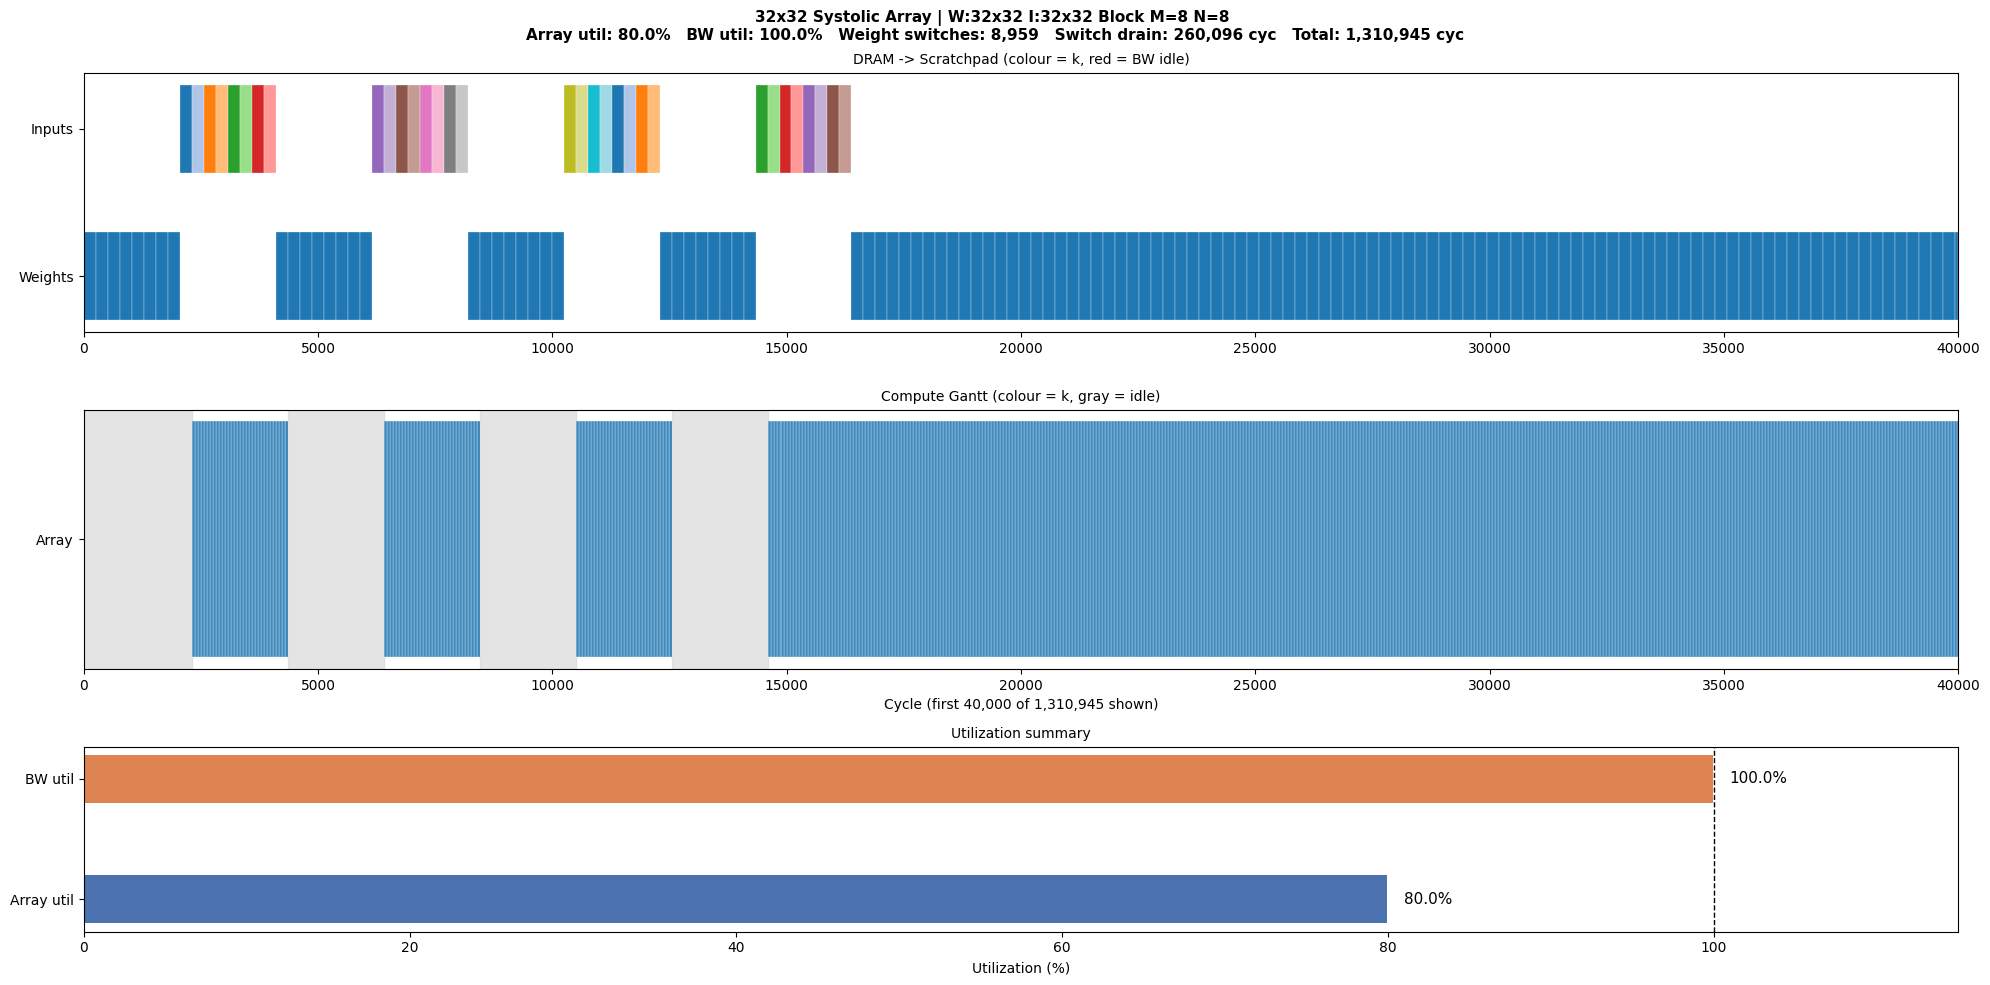

Plot -> /home/asicfab/a/socet149/atalla-sim/docs/smart_tile_scheduling_outputs/systolic_timeline_M8_N8.png


In [9]:
# Compare two medium-reuse cases with plots.

sim_16, metrics_16 = run_simulation(Mw=32, K=32, Ni=32, M=16, N=16, verbose=True, plot=True)
sim_8, metrics_8 = run_simulation(Mw=32, K=32, Ni=32, M=8, N=8, verbose=True, plot=True)

## Scratchpad Capacity Model

To choose a reuse block that fits in scratchpad, we need to account for all resident tile types at once.

For a block with:

- `M` weight tiles
- `N` activation tiles
- `M * N` partial-sum tiles

The minimum live footprint in tile units is:

`footprint_tiles = M + N + M * N`

If we want to overlap the next weight group while computing on the current group, add another `M` weight tiles. If we also want to prefetch the next activation group, add another `N` tiles.

This notebook defines **weight reuse** as:

- how many activation tiles each resident weight tile can be multiplied against before eviction
- in this block model, that reuse factor is `N`

So the main question becomes: for a fixed scratchpad budget, what is the largest feasible `N`?

In [10]:
SPAD_BYTES_DEFAULT = 2 * 1024 * 1024


def scratchpad_capacity_tiles(spad_bytes=SPAD_BYTES_DEFAULT, tile_bytes=TILE_BYTES):
    return int(spad_bytes) // int(tile_bytes)



def scratchpad_footprint_tiles(
    M,
    N,
    *,
    overlap_next_weights=True,
    overlap_next_inputs=False,
    reserve_tiles=0,
):
    current_weight_tiles = int(M)
    current_activation_tiles = int(N)
    partial_sum_tiles = int(M) * int(N)
    prefetched_weight_tiles = int(M) if overlap_next_weights else 0
    prefetched_activation_tiles = int(N) if overlap_next_inputs else 0

    total_tiles = (
        current_weight_tiles
        + current_activation_tiles
        + partial_sum_tiles
        + prefetched_weight_tiles
        + prefetched_activation_tiles
        + int(reserve_tiles)
    )

    return {
        "weight_tiles": current_weight_tiles,
        "activation_tiles": current_activation_tiles,
        "partial_sum_tiles": partial_sum_tiles,
        "prefetched_weight_tiles": prefetched_weight_tiles,
        "prefetched_activation_tiles": prefetched_activation_tiles,
        "reserve_tiles": int(reserve_tiles),
        "total_tiles": total_tiles,
        "total_bytes": total_tiles * TILE_BYTES,
    }



def max_weight_reuse_for_M(
    M,
    *,
    spad_bytes=SPAD_BYTES_DEFAULT,
    overlap_next_weights=True,
    overlap_next_inputs=False,
    reserve_tiles=0,
):
    capacity_tiles = scratchpad_capacity_tiles(spad_bytes=spad_bytes)
    best = None
    for N in range(1, capacity_tiles + 1):
        footprint = scratchpad_footprint_tiles(
            M,
            N,
            overlap_next_weights=overlap_next_weights,
            overlap_next_inputs=overlap_next_inputs,
            reserve_tiles=reserve_tiles,
        )
        if footprint["total_tiles"] > capacity_tiles:
            break
        best = {
            "M": int(M),
            "N": int(N),
            "weight_reuse": int(N),
            "ready_gemms": int(M) * int(N),
            "capacity_tiles": capacity_tiles,
            **footprint,
        }
    return best



def feasible_reuse_pairs(
    *,
    spad_bytes=SPAD_BYTES_DEFAULT,
    overlap_next_weights=True,
    overlap_next_inputs=False,
    reserve_tiles=0,
    max_M=None,
):
    capacity_tiles = scratchpad_capacity_tiles(spad_bytes=spad_bytes)
    limit_M = capacity_tiles if max_M is None else min(int(max_M), capacity_tiles)
    feasible = []
    for M in range(1, limit_M + 1):
        best_for_M = max_weight_reuse_for_M(
            M,
            spad_bytes=spad_bytes,
            overlap_next_weights=overlap_next_weights,
            overlap_next_inputs=overlap_next_inputs,
            reserve_tiles=reserve_tiles,
        )
        if best_for_M is not None:
            feasible.append(best_for_M)
    return feasible



def summarize_weight_reuse_budget(
    *,
    spad_bytes=SPAD_BYTES_DEFAULT,
    overlap_next_weights=True,
    overlap_next_inputs=False,
    reserve_tiles=0,
    max_M=128,
):
    capacity_tiles = scratchpad_capacity_tiles(spad_bytes=spad_bytes)
    feasible = feasible_reuse_pairs(
        spad_bytes=spad_bytes,
        overlap_next_weights=overlap_next_weights,
        overlap_next_inputs=overlap_next_inputs,
        reserve_tiles=reserve_tiles,
        max_M=max_M,
    )
    if not feasible:
        raise ValueError("No feasible reuse pairs fit in scratchpad")

    best_weight_reuse = max(feasible, key=lambda item: (item["weight_reuse"], -item["M"]))
    best_ready_gemms = max(feasible, key=lambda item: (item["ready_gemms"], item["weight_reuse"], -item["M"]))

    return {
        "scratchpad_bytes": int(spad_bytes),
        "tile_bytes": TILE_BYTES,
        "capacity_tiles": capacity_tiles,
        "overlap_next_weights": bool(overlap_next_weights),
        "overlap_next_inputs": bool(overlap_next_inputs),
        "reserve_tiles": int(reserve_tiles),
        "best_weight_reuse": best_weight_reuse,
        "best_ready_gemms": best_ready_gemms,
        "sample_points": feasible[: min(len(feasible), 12)],
    }



def print_weight_reuse_summary(summary):
    print(f"Scratchpad budget      : {summary['scratchpad_bytes']:,} bytes")
    print(f"Tile bytes             : {summary['tile_bytes']:,} bytes")
    print(f"Tile capacity          : {summary['capacity_tiles']:,} tiles")
    print(f"Overlap next weights   : {summary['overlap_next_weights']}")
    print(f"Overlap next inputs    : {summary['overlap_next_inputs']}")
    print(f"Reserved tiles         : {summary['reserve_tiles']}")
    print()

    best_reuse = summary['best_weight_reuse']
    print("Best weight reuse under budget:")
    print(
        f"  M={best_reuse['M']} N={best_reuse['N']} -> reuse={best_reuse['weight_reuse']} "
        f"with footprint {best_reuse['total_tiles']} tiles ({best_reuse['total_bytes']:,} bytes)"
    )
    print(
        f"  Breakdown: W={best_reuse['weight_tiles']} A={best_reuse['activation_tiles']} "
        f"PSUM={best_reuse['partial_sum_tiles']} "
        f"nextW={best_reuse['prefetched_weight_tiles']} nextA={best_reuse['prefetched_activation_tiles']}"
    )
    print()

    best_gemms = summary['best_ready_gemms']
    print("Best block for ready GEMMs under budget:")
    print(
        f"  M={best_gemms['M']} N={best_gemms['N']} -> M*N={best_gemms['ready_gemms']} "
        f"with footprint {best_gemms['total_tiles']} tiles ({best_gemms['total_bytes']:,} bytes)"
    )

In [11]:
summary_2mb = summarize_weight_reuse_budget(
    spad_bytes=2 * 1024 * 1024,
    overlap_next_weights=True,
    overlap_next_inputs=False,
    reserve_tiles=0,
    max_M=256,
)
print_weight_reuse_summary(summary_2mb)
summary_2mb

Scratchpad budget      : 2,097,152 bytes
Tile bytes             : 2,048 bytes
Tile capacity          : 1,024 tiles
Overlap next weights   : True
Overlap next inputs    : False
Reserved tiles         : 0

Best weight reuse under budget:
  M=1 N=511 -> reuse=511 with footprint 1024 tiles (2,097,152 bytes)
  Breakdown: W=1 A=511 PSUM=511 nextW=1 nextA=0

Best block for ready GEMMs under budget:
  M=18 N=52 -> M*N=936 with footprint 1024 tiles (2,097,152 bytes)


{'scratchpad_bytes': 2097152,
 'tile_bytes': 2048,
 'capacity_tiles': 1024,
 'overlap_next_weights': True,
 'overlap_next_inputs': False,
 'reserve_tiles': 0,
 'best_weight_reuse': {'M': 1,
  'N': 511,
  'weight_reuse': 511,
  'ready_gemms': 511,
  'capacity_tiles': 1024,
  'weight_tiles': 1,
  'activation_tiles': 511,
  'partial_sum_tiles': 511,
  'prefetched_weight_tiles': 1,
  'prefetched_activation_tiles': 0,
  'reserve_tiles': 0,
  'total_tiles': 1024,
  'total_bytes': 2097152},
 'best_ready_gemms': {'M': 18,
  'N': 52,
  'weight_reuse': 52,
  'ready_gemms': 936,
  'capacity_tiles': 1024,
  'weight_tiles': 18,
  'activation_tiles': 52,
  'partial_sum_tiles': 936,
  'prefetched_weight_tiles': 18,
  'prefetched_activation_tiles': 0,
  'reserve_tiles': 0,
  'total_tiles': 1024,
  'total_bytes': 2097152},
 'sample_points': [{'M': 1,
   'N': 511,
   'weight_reuse': 511,
   'ready_gemms': 511,
   'capacity_tiles': 1024,
   'weight_tiles': 1,
   'activation_tiles': 511,
   'partial_sum_t

### Interpreting the 2 MB Result

- **Maximum weight reuse** means maximizing `N`, the number of activation tiles a resident weight tile can be reused against.
  - Under the current footprint model, the best point is `M=1, N=511`.
- **Maximum ready GEMMs** means maximizing `M * N`, the number of output tile-GEMMs that can be made ready at once.
  - Under the same 2 MB budget, the best point is `M=18, N=52`.

For *weight reuse*, the important number is `N=511`. If your goal is *throughput-oriented block sizing*, the `M * N` optimum is often a better operating point.

## Scheduling The Best Ready-GEMM Point

Using the scratchpad-capacity result above, the best block for ready GEMMs is `M=18, N=52`

- Keep `18` weight tiles resident at once.
- Reuse them across `52` activation tiles.
- The block exposes `18 * 52 = 936` tile-GEMMs once all operands are present.

The key overlap threshold is:

`gemms_needed_to_hide_one_load = ceil(t_GEMM_load / t_GEMM_sysarr) = 6`

-> So one tile load can be hidden if the array already has at least `6` ready GEMMs queued behind it.

A practical low-ramp schedule is:

1. Warm up with one weight tile and six activation tiles: `A, 1, 2, 3, 4, 5, 6`.
2. Then stream in the remaining weight tiles: `B, C, ..., R`.
3. While loading a new weight tile, execute the six GEMMs created by the previous weight tile against activations `1..6`.

For example:

- while `B` loads, execute `A1..A6`
- while `C` loads, execute `B1..B6`
- while `D` loads, execute `C1..C6`

After the first six activation tiles are resident, every additional weight tile already has enough work to hide its own `256`-cycle load, because `6 * 45 = 270` cycles of compute are available.

That means the earliest point where the next activation tile could be loaded without exposing bandwidth is after `6` weights are resident. However, if the goal is to minimize ramp-up to the full `18`-weight working set, the better policy is:

- finish loading all weights `A..R` first
- then start loading activation tiles `7..52`

Reason: once activations `1..6` are present, weight streaming is already self-hiding. Starting activation `7` earlier would consume DRAM bandwidth that is better spent finishing the `18`-weight ramp as quickly as possible.

After all `18` weights are resident, each new activation tile creates `18` more ready GEMMs, so activation streaming is comfortably hidden by compute.

In [12]:
from math import ceil


def summarize_ready_gemm_schedule(M=18, N=52, load_cycles=256, gemm_cycles=45):
    gemms_needed_to_hide_one_load = ceil(load_cycles / gemm_cycles)
    earliest_activation_prefetch_after_weights = gemms_needed_to_hide_one_load
    recommended_activation_prefetch_after_weights = M

    load_per_block = (M + N) * load_cycles
    compute_per_block = M * N * gemm_cycles

    summary = {
        "M": int(M),
        "N": int(N),
        "load_cycles": int(load_cycles),
        "gemm_cycles": int(gemm_cycles),
        "gemms_needed_to_hide_one_load": int(gemms_needed_to_hide_one_load),
        "earliest_activation_prefetch_after_weights": int(earliest_activation_prefetch_after_weights),
        "recommended_activation_prefetch_after_weights": int(recommended_activation_prefetch_after_weights),
        "load_per_block": int(load_per_block),
        "compute_per_block": int(compute_per_block),
        "warmup_sequence": ["A", "1", "2", "3", "4", "5", "6"],
        "weight_stream": [chr(ord("A") + idx) for idx in range(M)],
        "activation_stream": [str(idx) for idx in range(1, N + 1)],
    }

    print(f"Best ready-GEMM block: M={M}, N={N}")
    print(f"Tile load latency     : {load_cycles} cycles")
    print(f"Tile GEMM latency     : {gemm_cycles} cycles")
    print(f"GEMMs needed/load     : {gemms_needed_to_hide_one_load}")
    print()
    print("Recommended schedule:")
    print("  Warm-up             : A, 1, 2, 3, 4, 5, 6")
    print(f"  Weight stream       : A..{chr(ord('A') + M - 1)}")
    print(f"  Activation stream   : 1..{N}")
    print(f"  Earliest next activation prefetch: after {earliest_activation_prefetch_after_weights} weights are resident")
    print(f"  Recommended next activation prefetch: after all {recommended_activation_prefetch_after_weights} weights are resident")
    print()
    print(f"Per-block load time   : {load_per_block:,} cycles")
    print(f"Per-block compute time: {compute_per_block:,} cycles")
    print(f"Block bound           : {'COMPUTE' if compute_per_block > load_per_block else 'MEMORY'}")
    return summary


ready_gemm_schedule_summary = summarize_ready_gemm_schedule()
ready_gemm_schedule_summary

Best ready-GEMM block: M=18, N=52
Tile load latency     : 256 cycles
Tile GEMM latency     : 45 cycles
GEMMs needed/load     : 6

Recommended schedule:
  Warm-up             : A, 1, 2, 3, 4, 5, 6
  Weight stream       : A..R
  Activation stream   : 1..52
  Earliest next activation prefetch: after 6 weights are resident
  Recommended next activation prefetch: after all 18 weights are resident

Per-block load time   : 17,920 cycles
Per-block compute time: 42,120 cycles
Block bound           : COMPUTE


{'M': 18,
 'N': 52,
 'load_cycles': 256,
 'gemm_cycles': 45,
 'gemms_needed_to_hide_one_load': 6,
 'earliest_activation_prefetch_after_weights': 6,
 'recommended_activation_prefetch_after_weights': 18,
 'load_per_block': 17920,
 'compute_per_block': 42120,
 'warmup_sequence': ['A', '1', '2', '3', '4', '5', '6'],
 'weight_stream': ['A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R'],
 'activation_stream': ['1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17',
  '18',
  '19',
  '20',
  '21',
  '22',
  '23',
  '24',
  '25',
  '26',
  '27',
  '28',
  '29',
  '30',
  '31',
  '32',
  '33',
  '34',
  '35',
  '36',
  '37',
  '38',
  '39',
  '40',
  '41',
  '42',
  '43',
  '44',
  '45',
  '46',
  '47',
  '48',
  '49',
  '50',
  '51',
  '52']}

## Utilization Surface and DRAM Bandwidth Sweep

This section adds two design-space plots:

- a simulated `M`/`N` utilization surface at a chosen DRAM bandwidth
- a DRAM-bandwidth sweep for the best reuse point found on that surface

The bandwidth sweep answers the practical sizing question: how much does DRAM bandwidth need to increase before array utilization stops improving meaningfully?

The recommendation uses a simple knee rule:

- find the peak utilization reached in the bandwidth sweep
- recommend the smallest bandwidth that reaches `95%` of that peak

If the current `8 B/cycle` point already meets that threshold, the notebook will say that more DRAM bandwidth is not the limiting factor under this schedule.

In [13]:
from contextlib import contextmanager
import math

import numpy as np


SIMULATION_METRICS_CACHE = {}


def bandwidth_label(dram_bw):
    return f"{float(dram_bw):g}".replace(".", "p")



def load_cycles_for_bw(dram_bw, tile_bytes=TILE_BYTES):
    dram_bw = float(dram_bw)
    if dram_bw <= 0:
        raise ValueError("dram_bw must be positive")
    return math.ceil(tile_bytes / dram_bw)



def valid_reuse_sizes(dim):
    return [value for value in range(1, dim + 1) if dim % value == 0]



@contextmanager
def temporary_dram_bandwidth(dram_bw):
    global DRAM_BW, LOAD_CYCLES

    previous_bw = DRAM_BW
    previous_load_cycles = LOAD_CYCLES
    DRAM_BW = float(dram_bw)
    LOAD_CYCLES = load_cycles_for_bw(dram_bw)
    try:
        yield LOAD_CYCLES
    finally:
        DRAM_BW = previous_bw
        LOAD_CYCLES = previous_load_cycles



def collect_simulation_metrics(Mw=32, K=32, Ni=32, M=32, N=32, dram_bw=8):
    load_cycles = load_cycles_for_bw(dram_bw)
    cache_key = (int(Mw), int(K), int(Ni), int(M), int(N), int(load_cycles))
    cached = SIMULATION_METRICS_CACHE.get(cache_key)
    if cached is not None:
        return dict(cached)

    with temporary_dram_bandwidth(dram_bw):
        sim = SystolicArraySim(Mw=Mw, K=K, Ni=Ni, M=M, N=N).run()
        metrics = sim.metrics()

    metrics = {
        **metrics,
        "Mw": int(Mw),
        "K": int(K),
        "Ni": int(Ni),
        "M": int(M),
        "N": int(N),
        "dram_bw": float(dram_bw),
        "load_cycles": int(load_cycles),
        "block_load_cycles": int((M + N) * load_cycles),
        "block_compute_cycles": int(M * N * COMPUTE_CYCLES),
    }
    metrics["theoretical_bound"] = (
        "COMPUTE" if metrics["block_compute_cycles"] > metrics["block_load_cycles"] else "MEMORY"
    )
    metrics["theoretical_array_util_pct"] = min(
        100.0,
        metrics["block_compute_cycles"] / max(metrics["block_load_cycles"], 1) * 100.0,
    )

    SIMULATION_METRICS_CACHE[cache_key] = dict(metrics)
    return dict(metrics)



def sweep_mn_utilization_surface(Mw=32, K=32, Ni=32, dram_bw=8, m_values=None, n_values=None):
    m_values = valid_reuse_sizes(Mw) if m_values is None else list(m_values)
    n_values = valid_reuse_sizes(Ni) if n_values is None else list(n_values)

    util_grid = np.full((len(m_values), len(n_values)), np.nan, dtype=float)
    results = []
    best = None

    for row_index, M in enumerate(m_values):
        for col_index, N in enumerate(n_values):
            if Mw % M != 0 or Ni % N != 0:
                continue
            metrics = collect_simulation_metrics(Mw=Mw, K=K, Ni=Ni, M=M, N=N, dram_bw=dram_bw)
            util_grid[row_index, col_index] = metrics["array_util_pct"]
            results.append(metrics)
            if best is None or metrics["array_util_pct"] > best["array_util_pct"]:
                best = metrics

    return {
        "Mw": int(Mw),
        "K": int(K),
        "Ni": int(Ni),
        "dram_bw": float(dram_bw),
        "m_values": np.array(m_values),
        "n_values": np.array(n_values),
        "util_grid": util_grid,
        "results": results,
        "best": best,
    }



def plot_mn_utilization_surface(surface, elev=28, azim=-135):
    m_values = surface["m_values"]
    n_values = surface["n_values"]
    util_grid = surface["util_grid"]
    best = surface["best"]

    M_grid, N_grid = np.meshgrid(m_values, n_values, indexing="ij")

    fig = plt.figure(figsize=(17, 6))
    ax0 = fig.add_subplot(1, 2, 1, projection="3d")
    surface_artist = ax0.plot_surface(
        M_grid,
        N_grid,
        util_grid,
        cmap="viridis",
        edgecolor="white",
        linewidth=0.7,
        antialiased=True,
        alpha=0.92,
    )
    ax0.scatter(
        [best["M"]],
        [best["N"]],
        [best["array_util_pct"]],
        color="crimson",
        s=90,
        label=f"best = ({best['M']}, {best['N']})",
    )
    ax0.set_xlabel("M (weight reuse rows)")
    ax0.set_ylabel("N (activation reuse cols)")
    ax0.set_zlabel("Systolic array util (%)")
    ax0.set_title(f"Utilization surface at DRAM BW = {surface['dram_bw']:g} B/cycle")
    ax0.view_init(elev=elev, azim=azim)
    ax0.legend(loc="upper left")
    fig.colorbar(surface_artist, ax=ax0, shrink=0.8, pad=0.08, label="Utilization (%)")

    ax1 = fig.add_subplot(1, 2, 2)
    image = ax1.imshow(util_grid, origin="lower", cmap="viridis", aspect="auto")
    ax1.set_xticks(np.arange(len(n_values)), labels=n_values)
    ax1.set_yticks(np.arange(len(m_values)), labels=m_values)
    ax1.set_xlabel("N (activation reuse cols)")
    ax1.set_ylabel("M (weight reuse rows)")
    ax1.set_title("Exact utilization values")

    value_threshold = np.nanmean(util_grid)
    for row_index, M in enumerate(m_values):
        for col_index, N in enumerate(n_values):
            value = util_grid[row_index, col_index]
            if np.isnan(value):
                continue
            text_color = "black" if value >= value_threshold else "white"
            ax1.text(col_index, row_index, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=9)

    best_row = int(np.where(m_values == best["M"])[0][0])
    best_col = int(np.where(n_values == best["N"])[0][0])
    ax1.scatter(best_col, best_row, s=170, facecolors="none", edgecolors="crimson", linewidths=2)
    fig.colorbar(image, ax=ax1, fraction=0.046, pad=0.04, label="Utilization (%)")

    plt.tight_layout()
    output_path = OUTPUT_DIR / f"mn_utilization_surface_bw{bandwidth_label(surface['dram_bw'])}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot -> {output_path}")
    return output_path



def sweep_dram_bw_utilization(Mw=32, K=32, Ni=32, M=32, N=32, dram_bw_values=None):
    if dram_bw_values is None:
        dram_bw_values = [4, 6, 8, 10, 12, 16, 24, 32, 48, 64]

    points = []
    for dram_bw in dram_bw_values:
        metrics = collect_simulation_metrics(Mw=Mw, K=K, Ni=Ni, M=M, N=N, dram_bw=dram_bw)
        points.append(metrics)

    return {
        "Mw": int(Mw),
        "K": int(K),
        "Ni": int(Ni),
        "M": int(M),
        "N": int(N),
        "points": points,
    }



def recommend_dram_bw(curve, current_bw=8, target_peak_fraction=0.95):
    points = sorted(curve["points"], key=lambda item: item["dram_bw"])
    peak_point = max(points, key=lambda item: item["array_util_pct"])
    target_util_pct = peak_point["array_util_pct"] * float(target_peak_fraction)

    minimum_point = next(
        (point for point in points if point["array_util_pct"] >= target_util_pct),
        peak_point,
    )
    current_point = next(
        (point for point in points if math.isclose(point["dram_bw"], float(current_bw))),
        collect_simulation_metrics(
            Mw=curve["Mw"],
            K=curve["K"],
            Ni=curve["Ni"],
            M=curve["M"],
            N=curve["N"],
            dram_bw=current_bw,
        ),
    )

    recommended_bw = max(float(current_bw), minimum_point["dram_bw"])
    recommended_util_pct = (
        current_point["array_util_pct"] if math.isclose(recommended_bw, float(current_bw)) else minimum_point["array_util_pct"]
    )

    return {
        "current_bw": float(current_bw),
        "current_util_pct": current_point["array_util_pct"],
        "peak_bw": peak_point["dram_bw"],
        "peak_util_pct": peak_point["array_util_pct"],
        "target_peak_fraction": float(target_peak_fraction),
        "target_util_pct": target_util_pct,
        "minimum_bw_for_target": minimum_point["dram_bw"],
        "minimum_util_pct_for_target": minimum_point["array_util_pct"],
        "recommended_bw": recommended_bw,
        "recommended_util_pct": recommended_util_pct,
        "needs_bw_increase": recommended_bw > float(current_bw),
        "bw_increase_pct": max(0.0, (recommended_bw / float(current_bw) - 1.0) * 100.0),
    }



def plot_dram_bw_utilization(curve, recommendation):
    points = sorted(curve["points"], key=lambda item: item["dram_bw"])
    bw_values = [point["dram_bw"] for point in points]
    util_values = [point["array_util_pct"] for point in points]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(
        bw_values,
        util_values,
        marker="o",
        linewidth=2.5,
        color="#1f77b4",
        label=f"M={curve['M']}, N={curve['N']}",
    )
    ax.axvline(
        recommendation["current_bw"],
        color="#dd8452",
        linestyle="--",
        linewidth=1.7,
        label=f"current = {recommendation['current_bw']:g} B/cycle",
    )
    ax.axvline(
        recommendation["minimum_bw_for_target"],
        color="crimson",
        linestyle=":",
        linewidth=2.0,
        label=f"95% peak knee = {recommendation['minimum_bw_for_target']:g} B/cycle",
    )
    ax.axhline(
        recommendation["target_util_pct"],
        color="gray",
        linestyle="--",
        linewidth=1.2,
        label=f"95% of peak = {recommendation['target_util_pct']:.1f}%",
    )
    ax.scatter(
        [recommendation["current_bw"], recommendation["minimum_bw_for_target"]],
        [recommendation["current_util_pct"], recommendation["minimum_util_pct_for_target"]],
        color=["#dd8452", "crimson"],
        s=80,
        zorder=5,
    )
    ax.set_xlabel("DRAM bandwidth (B/cycle)")
    ax.set_ylabel("Systolic array util (%)")
    ax.set_title(
        f"Utilization vs DRAM bandwidth for reuse point M={curve['M']}, N={curve['N']}"
    )
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

    plt.tight_layout()
    output_path = OUTPUT_DIR / f"dram_bw_utilization_M{curve['M']}_N{curve['N']}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot -> {output_path}")
    return output_path



def run_bandwidth_study(
    Mw=32,
    K=32,
    Ni=32,
    current_bw=8,
    dram_bw_values=None,
    target_peak_fraction=0.95,
):
    surface = sweep_mn_utilization_surface(Mw=Mw, K=K, Ni=Ni, dram_bw=current_bw)
    surface_plot_path = plot_mn_utilization_surface(surface)

    best_point = surface["best"]
    print(
        f"Best reuse point at {current_bw:g} B/cycle: M={best_point['M']} N={best_point['N']} "
        f"-> {best_point['array_util_pct']:.2f}% util"
    )

    curve = sweep_dram_bw_utilization(
        Mw=Mw,
        K=K,
        Ni=Ni,
        M=best_point["M"],
        N=best_point["N"],
        dram_bw_values=dram_bw_values,
    )
    recommendation = recommend_dram_bw(
        curve,
        current_bw=current_bw,
        target_peak_fraction=target_peak_fraction,
    )
    curve_plot_path = plot_dram_bw_utilization(curve, recommendation)

    print()
    print("Bandwidth recommendation:")
    print(f"  Current BW              : {recommendation['current_bw']:g} B/cycle")
    print(f"  Current util            : {recommendation['current_util_pct']:.2f}%")
    print(f"  Peak util in sweep      : {recommendation['peak_util_pct']:.2f}%")
    print(f"  95% of peak util        : {recommendation['target_util_pct']:.2f}%")
    print(f"  Minimum BW for 95% peak : {recommendation['minimum_bw_for_target']:g} B/cycle")
    if recommendation["needs_bw_increase"]:
        print(f"  Recommended BW          : {recommendation['recommended_bw']:g} B/cycle")
        print(f"  BW increase vs now      : {recommendation['bw_increase_pct']:.1f}%")
    else:
        print(f"  Recommended BW          : keep {recommendation['current_bw']:g} B/cycle")
        print("  BW increase vs now      : 0.0% (already beyond the 95% knee)")

    return {
        "surface": surface,
        "surface_plot_path": surface_plot_path,
        "best_point": best_point,
        "bw_curve": curve,
        "bw_curve_plot_path": curve_plot_path,
        "recommendation": recommendation,
    }

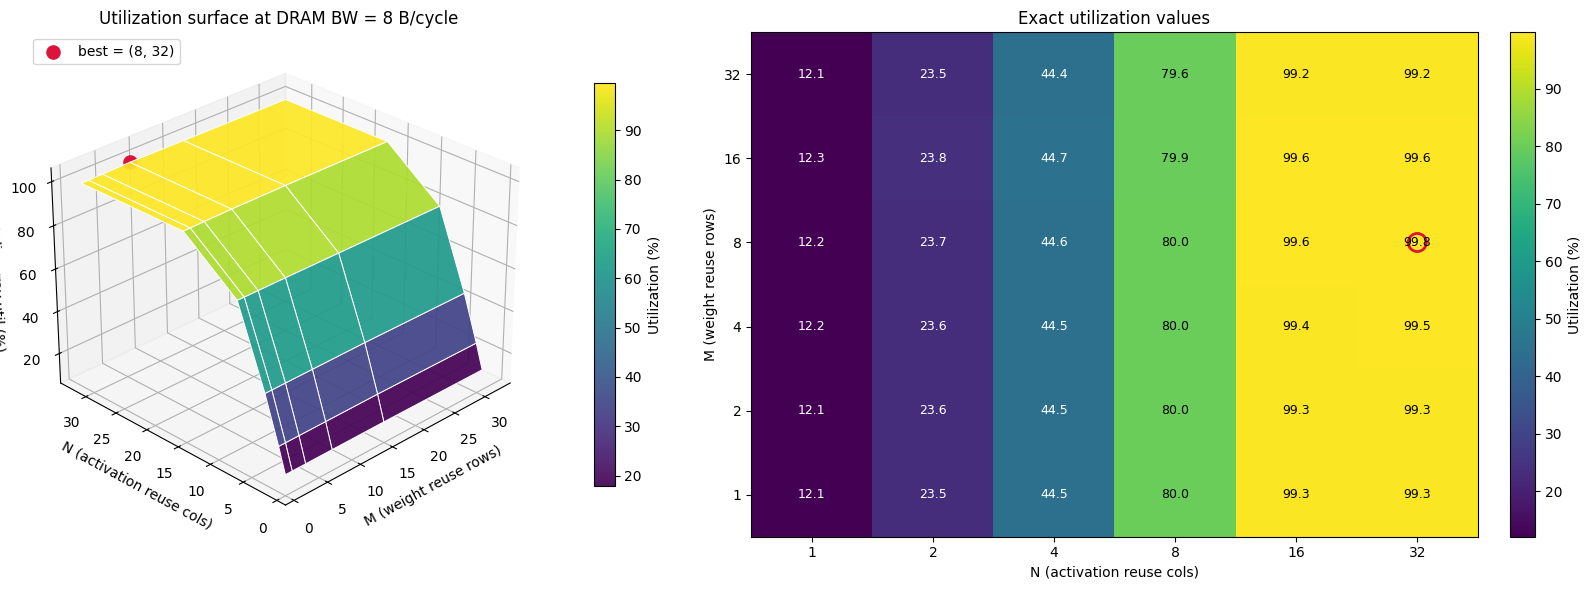

Plot -> /home/asicfab/a/socet149/atalla-sim/docs/smart_tile_scheduling_outputs/mn_utilization_surface_bw8.png
Best reuse point at 8 B/cycle: M=8 N=32 -> 99.78% util


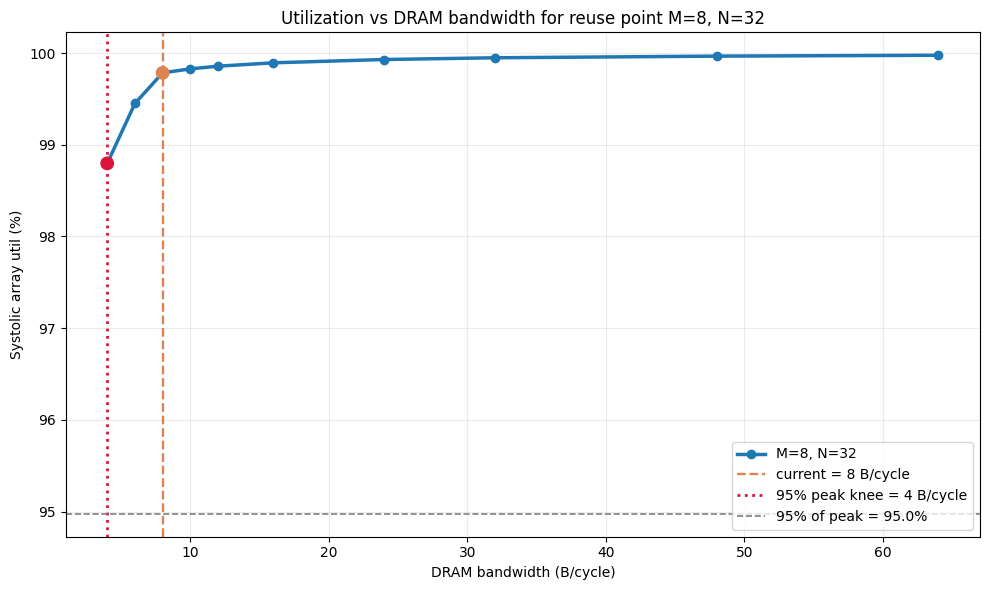

Plot -> /home/asicfab/a/socet149/atalla-sim/docs/smart_tile_scheduling_outputs/dram_bw_utilization_M8_N32.png

Bandwidth recommendation:
  Current BW              : 8 B/cycle
  Current util            : 99.78%
  Peak util in sweep      : 99.98%
  95% of peak util        : 94.98%
  Minimum BW for 95% peak : 4 B/cycle
  Recommended BW          : keep 8 B/cycle
  BW increase vs now      : 0.0% (already beyond the 95% knee)


{'current_bw': 8.0,
 'current_util_pct': 99.78369870457125,
 'peak_bw': 64.0,
 'peak_util_pct': 99.97549657571795,
 'target_peak_fraction': 0.95,
 'target_util_pct': 94.97672174693206,
 'minimum_bw_for_target': 4.0,
 'minimum_util_pct_for_target': 98.79690392850581,
 'recommended_bw': 8.0,
 'recommended_util_pct': 99.78369870457125,
 'needs_bw_increase': False,
 'bw_increase_pct': 0.0}

In [14]:
bandwidth_study = run_bandwidth_study(
    Mw=32,
    K=32,
    Ni=32,
    current_bw=8,
    dram_bw_values=[4, 6, 8, 10, 12, 16, 24, 32, 48, 64],
    target_peak_fraction=0.95,
)

bandwidth_study["recommendation"]